##### 📦 IMPORTS

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
col, regexp_replace, sum, avg, desc, round,
substring, max, min, concat, lit,
count, year, month, to_date, countDistinct
)

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import builtins

##### ⚙️ CONFIGURAÇÃO DO SPARK

In [2]:
spark = SparkSession.builder \
.appName("Bolsa Familia 2026") \
.config("spark.driver.memory", "8g") \
.config("spark.executor.memory", "8g") \
.config("spark.sql.shuffle.partitions", "50") \
.getOrCreate()

##### 📂 LEITURA DOS DADOS

In [3]:
caminho_csv = "../dados/NovoBolsaFamilia26.csv"

df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("sep", ";") \
    .option("encoding", "ISO-8859-1") \
    .csv(caminho_csv)

print("\n--- DADOS ORIGINAIS ---")
df.show(5)


--- DADOS ORIGINAIS ---
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|MÊS COMPETÊNCIA|MÊS REFERÊNCIA| UF|CÓDIGO MUNICÍPIO SIAFI|NOME MUNICÍPIO|CPF FAVORECIDO|NIS FAVORECIDO|     NOME FAVORECIDO|VALOR PARCELA|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|         202601|        202502| MG|                  5041|    PONTE NOVA|          NULL|   16523667112|MILENE APARECIDA ...|       850,00|
|         202601|        202502| RO|                     5|     JI-PARANA|***.582.082-**|   16224642940|GLEISIMAR LIMA SILVA|       750,00|
|         202601|        202503| MG|                  5041|    PONTE NOVA|          NULL|   16523667112|MILENE APARECIDA ...|       850,00|
|         202601|        202505| SP|                  2965|      BERTIOGA|***.740.014-**|   20619521036|LIGIA SAMARA LIMA...|       800

##### 🧹 PADRONIZAÇÃO DE COLUNAS

In [4]:
colunas_padrao = {
    "MÊS COMPETÊNCIA": "data_competencia",
    "MÊS REFERÊNCIA": "data_referencia",
    "CÓDIGO MUNICÍPIO SIAFI": "codigo_municipio",
    "UF": "uf",
    "NOME MUNICÍPIO": "nome_municipio",
    "CPF FAVORECIDO": "cpf_favorecido",
    "NIS FAVORECIDO": "nis_favorecido",
    "NOME FAVORECIDO": "nome_favorecido",
    "VALOR PARCELA": "valor_parcela"
}

for antiga, nova in colunas_padrao.items():
    df = df.withColumnRenamed(antiga, nova)

##### 🔄 TRATAMENTO DOS DADOS

In [5]:
df_tratado = (
    df
    .dropna()
    .withColumn(
        "valor_parcela",
        regexp_replace(col("valor_parcela"), ",", ".").cast("decimal(10,2)")
    )
    .withColumn(
        "data_competencia_data",
        to_date(
            concat(
                substring(col("data_competencia"), 1, 4),
                lit("-"),
                substring(col("data_competencia"), 5, 2),
                lit("-01")
            )
        )
    )
    .withColumn("ano_competencia", substring(col("data_competencia"), 1, 4))
    .withColumn("mes_competencia", substring(col("data_competencia"), 5, 2))
)

print("\n--- DADOS TRATADOS ---")
df_tratado.show(5)
df_tratado.printSchema()


--- DADOS TRATADOS ---
+----------------+---------------+---+----------------+--------------+--------------+--------------+--------------------+-------------+---------------------+---------------+---------------+
|data_competencia|data_referencia| uf|codigo_municipio|nome_municipio|cpf_favorecido|nis_favorecido|     nome_favorecido|valor_parcela|data_competencia_data|ano_competencia|mes_competencia|
+----------------+---------------+---+----------------+--------------+--------------+--------------+--------------------+-------------+---------------------+---------------+---------------+
|          202601|         202502| RO|               5|     JI-PARANA|***.582.082-**|   16224642940|GLEISIMAR LIMA SILVA|       750.00|           2026-01-01|           2026|             01|
|          202601|         202505| SP|            2965|      BERTIOGA|***.740.014-**|   20619521036|LIGIA SAMARA LIMA...|       800.00|           2026-01-01|           2026|             01|
|          202601|        

##### 3.1. RESULTADOS GERAIS E FATURAMENTO

In [6]:
df_stats = df_tratado.withColumn("valor_parcela", col("valor_parcela").cast("decimal(10,2)"))

resumo = df_stats.agg(
    round(sum("valor_parcela"), 2).alias("total_pago"),
    round(avg("valor_parcela"), 2).alias("media_geral"),
    round(max("valor_parcela"), 2).alias("valor_maximo"),
    round(min("valor_parcela"), 2).alias("valor_minimo")
)

resumo_row = resumo.collect()[0]
total_pago_raw = float(resumo_row['total_pago'])
faturamento_limpo = "{:,.2f}".format(total_pago_raw).replace(",", "X").replace(".", ",").replace("X", ".")

print("="*60)
print(f"FATURAMENTO TOTAL (INVESTIMENTO): R$ {faturamento_limpo}")
print("="*60)
resumo.show()

FATURAMENTO TOTAL (INVESTIMENTO): R$ 10.179.732.078,00
+--------------+-----------+------------+------------+
|    total_pago|media_geral|valor_maximo|valor_minimo|
+--------------+-----------+------------+------------+
|10179732078.00|     667.33|     3956.00|       25.00|
+--------------+-----------+------------+------------+



##### 3.2. MÉDIA POR UF

In [7]:
media_uf = df_tratado.groupBy("uf") \
    .agg(round(avg("valor_parcela"), 2).alias("media_pago_uf")) \
    .orderBy(desc("media_pago_uf"))

print("Média de Pagamento por Estado:")
display(media_uf.toPandas()) 

Média de Pagamento por Estado:


,uf,media_pago_uf
0,RR,735.48
1,AP,722.47
2,AM,722.33
3,AC,718.42
4,PA,691.79
5,MA,690.85
6,TO,682.83
7,MT,681.02
8,MS,679.94
9,AL,676.56


##### 3.3 RANKING TOP 5 ESTADOS

In [8]:
top_5_estados = df_tratado.groupBy("uf") \
    .agg(round(sum("valor_parcela"), 2).alias("total_acumulado_uf")) \
    .orderBy(desc("total_acumulado_uf")) \
    .limit(5)

print("Os 5 Estados com maior investimento total:")
display(top_5_estados.toPandas())

Os 5 Estados com maior investimento total:


,uf,total_acumulado_uf
0,BA,1293326167.00
1,SP,1089651743.00
2,PE,824412747.00
3,CE,773814612.00
4,MG,747221996.00


##### 3.4 RANKING DAS PESSOAS QUE MAIS RECEBERAM

In [9]:
ranking_cpf = df_tratado.groupBy("cpf_favorecido", "nome_favorecido") \
    .agg(
        round(sum("valor_parcela"), 2).alias("valor_total_pessoa"),
        count("valor_parcela").alias("quantidade_parcelas")
    ) \
    .orderBy(desc("valor_total_pessoa")) \
    .limit(10)

print("Top 10 Beneficiários por Valor Acumulado:")
display(ranking_cpf.toPandas())

Top 10 Beneficiários por Valor Acumulado:


,cpf_favorecido,nome_favorecido,valor_total_pessoa,quantidade_parcelas
0,***.861.196-**,PATRICIA DIAS DA SILVA,18432.00,8
1,***.660.318-**,VIVIANE DE FREITAS REZENDE,17178.00,7
2,***.209.352-**,ANTONIA ANGELA BARBOSA SILVA PEREIRA,14624.00,8
3,***.361.267-**,JOCASTA MATOS,14490.00,7
4,***.947.741-**,ADRIANA FERREIRA DE ALMEIDA,14274.00,8
5,***.016.018-**,PAULA CRISTINA DO CARMO,14224.00,8
6,***.535.028-**,MARIE ANNE CARVALHO DE ANDRADE,14140.00,7
7,***.422.168-**,CELMA LOPES,13734.00,7
8,***.963.572-**,RONILMA DO SOCORRO DA CRUZ PEREIRA,13734.00,7
9,***.881.113-**,FRANCISCA DA SILVA FERREIRA,13360.00,8


##### 3.5 QUANTIDADE DE BENEFICIÁRIOS

In [10]:
# 1. Total Geral Único
total_cpfs = df_tratado.agg(countDistinct("cpf_favorecido").alias("total_beneficiarios_unicos")).collect()[0][0]

# 2. Por UF
beneficiarios_por_uf = df_tratado.groupBy("uf") \
    .agg(countDistinct("cpf_favorecido").alias("qtd_beneficiarios_uf")) \
    .orderBy(desc("qtd_beneficiarios_uf"))

print("="*60)
print(f"TOTAL DE CPFs ÚNICOS ATENDIDOS: {total_cpfs:,}".replace(',', '.'))
print("="*60)
print("\nDISTRIBUIÇÃO DE BENEFICIARIO POR UF:")
display(beneficiarios_por_uf.toPandas())

TOTAL DE CPFs ÚNICOS ATENDIDOS: 997.304

DISTRIBUIÇÃO DE BENEFICIARIO POR UF:


,uf,qtd_beneficiarios_uf
0,SP,296988
1,BA,224182
2,MG,200024
3,RJ,168725
4,GO,158022
5,MA,154737
6,PE,154008
7,CE,153813
8,PA,141552
9,PR,137718


##### CÁLCULO DE AMPLITUDE (Equidade 2026)

In [11]:
amplitude_26 = float(resumo_row['valor_maximo'] - resumo_row['valor_minimo'])

print("="*60)
print(f"ANÁLISE DE EQUIDADE 2026")
print("="*60)
print(f"Amplitude (Maior vs Menor Valor): R$ {amplitude_26:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print("="*60)

ANÁLISE DE EQUIDADE 2026
Amplitude (Maior vs Menor Valor): R$ 3.931,00


##### 📊 GRÁFICO 1 - TOP 5 UFs

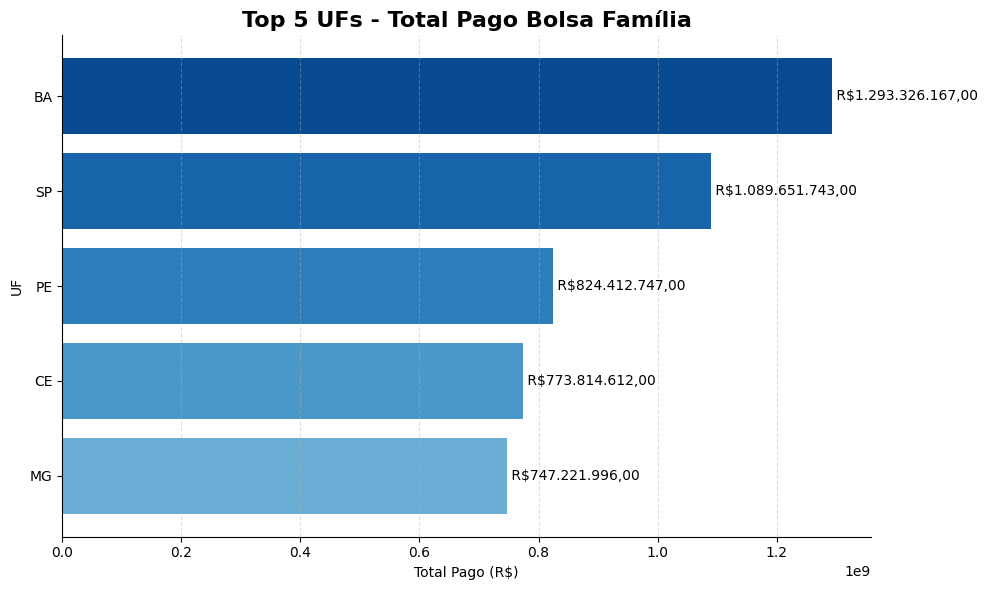

In [12]:
# 📊 GRÁFICO 1 - TOP 5 UFs
df_uf = df_tratado.groupBy("uf") \
    .agg(sum("valor_parcela").alias("total_pago")) \
    .orderBy("total_pago", ascending=False) \
    .limit(5) \
    .toPandas()

df_uf = df_uf.sort_values(by="total_pago", ascending=True)
colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(df_uf)))

plt.figure(figsize=(10, 6))
bars = plt.barh(df_uf["uf"], df_uf["total_pago"], color=colors)

plt.title("Top 5 UFs - Total Pago Bolsa Família", fontsize=16, fontweight='bold')
plt.xlabel("Total Pago (R$)")
plt.ylabel("UF")
plt.grid(axis='x', linestyle='--', alpha=0.4)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

def formatar_real(valor):
    return f'R${valor:,.2f}'.replace(",", "X").replace(".", ",").replace("X", ".")

for bar in bars:
    largura = bar.get_width()
    plt.text(largura, bar.get_y() + bar.get_height()/2, 
             f' {formatar_real(largura)}', va='center')

plt.tight_layout()
plt.savefig("top_ufs_bolsa_familia.png", dpi=300, bbox_inches='tight')
plt.show()

##### 📊 GRÁFICO 2 - SALTO ORÇAMENTÁRIO

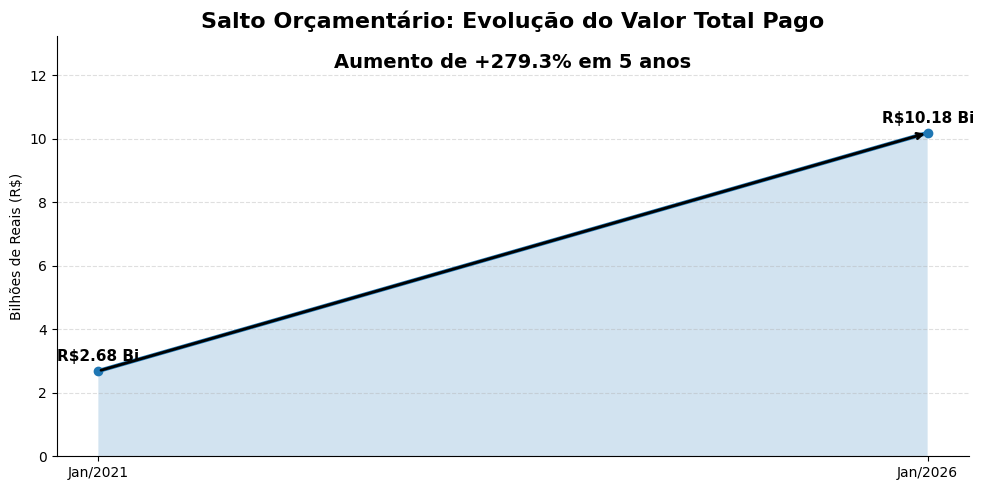

In [13]:
periodos = ['Jan/2021', 'Jan/2026']

valor_2021 = 2683780840.00 / 1e9
valor_2026 = float(resumo_row['total_pago']) / 1e9

faturamentos_bi = [valor_2021, valor_2026]
crescimento = ((valor_2026 - valor_2021) / valor_2021) * 100

ano_inicio = int(periodos[0].split('/')[1])
ano_fim = int(periodos[1].split('/')[1])
anos = ano_fim - ano_inicio

texto_crescimento = f"Aumento de +{crescimento:.1f}% em {anos} anos"

plt.figure(figsize=(10, 5))

# Linha e Área
plt.plot(periodos, faturamentos_bi, marker='o', linewidth=3)
plt.fill_between(periodos, faturamentos_bi, alpha=0.2)

# Rótulos dos valores
for i, v in enumerate(faturamentos_bi):
    plt.text(i, v + 0.3, f'R${v:.2f} Bi', ha='center', fontsize=11, fontweight='bold')

# Texto principal automático
max_valor = builtins.max(faturamentos_bi)
plt.text(0.5, max_valor * 1.2, texto_crescimento, ha='center', fontsize=14, fontweight='bold')

# Seta de evolução
plt.annotate('', xy=(1, valor_2026), xytext=(0, valor_2021),
             arrowprops=dict(arrowstyle='->', linewidth=2))

plt.title('Salto Orçamentário: Evolução do Valor Total Pago', fontsize=16, fontweight='bold')
plt.ylabel('Bilhões de Reais (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.ylim(0, max_valor * 1.3)
plt.tight_layout()
plt.savefig("salto_orcamentario.png", dpi=300, bbox_inches='tight')
plt.show()

##### 📊 GRÁFICO 3 - COMPARATIVO 2021 x 2026

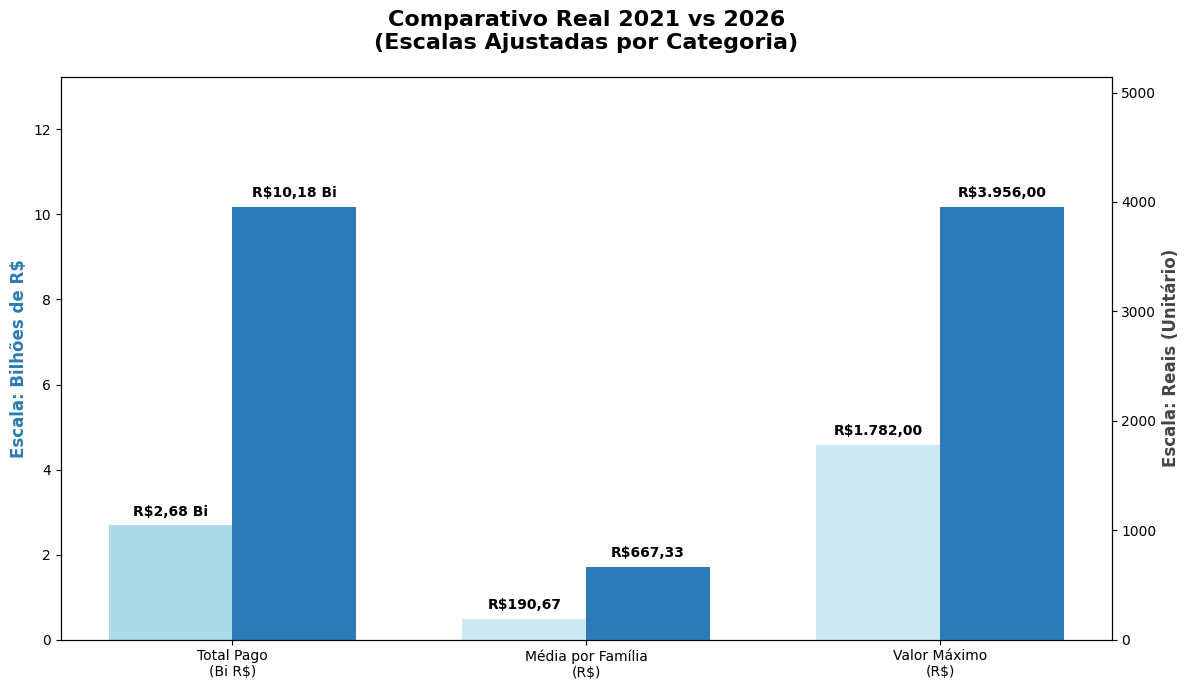

In [14]:
total_26 = 10179732078.00 / 1e9  
media_26 = 667.33
max_26 = 3956.00

total_21 = 2683780840.00 / 1e9  
media_21 = 190.67
max_21 = 1782.00

labels = ['Total Pago', 'Média', 'Máximo']
valores_21 = [total_21, media_21, max_21]
valores_26 = [total_26, media_26, max_26]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7), facecolor='white')
ax2 = ax1.twinx()

# Barras
rects1_total = ax1.bar(x[0] - width/2, valores_21[0], width, label='2021', color='#abd9e9')
rects1_resto = ax2.bar(x[1:] - width/2, valores_21[1:], width, color='#abd9e9', alpha=0.6)

rects2_total = ax1.bar(x[0] + width/2, valores_26[0], width, label='2025', color='#2c7bb6')
rects2_resto = ax2.bar(x[1:] + width/2, valores_26[1:], width, color='#2c7bb6')

# Ajustes
ax1.set_ylabel('Escala: Bilhões de R$', fontsize=12, fontweight='bold', color='#2c7bb6')
ax2.set_ylabel('Escala: Reais (Unitário)', fontsize=12, fontweight='bold', color='#444444')
ax1.set_title('Comparativo Real 2021 vs 2026\n(Escalas Ajustadas por Categoria)', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(['Total Pago\n(Bi R$)', 'Média por Família\n(R$)', 'Valor Máximo\n(R$)'])

def label_bars(rects, ax, suffix="", is_bi=False):
    for rect in rects:
        height = rect.get_height()
        val_form = f'R${height:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
        ax.annotate(f'{val_form}{suffix}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

label_bars(rects1_total, ax1, " Bi")
label_bars(rects2_total, ax1, " Bi")
label_bars(rects1_resto, ax2)
label_bars(rects2_resto, ax2)

ax1.set_ylim(0, total_26 * 1.3)
ax2.set_ylim(0, max_26 * 1.3)

plt.tight_layout()
plt.savefig("comparativo_2021X2026.png", dpi=300, bbox_inches='tight')
plt.show()

##### 📊 GRÁFICO INTERATIVO - MÉDIA POR UF

In [16]:
df_media_uf = df_tratado.groupBy("uf") \
    .agg(avg("valor_parcela").alias("media_pago")) \
    .orderBy("media_pago", ascending=False).toPandas()

df_media_uf["media_pago"] = df_media_uf["media_pago"].astype(float)

fig = px.bar(
    df_media_uf,
    x='uf',
    y='media_pago',
    title='<b>DISTRIBUIÇÃO DA MÉDIA POR ESTADO | JANEIRO 2025</b>',
    labels={'uf': 'Estado', 'media_pago': 'Valor Médio (R$)'},
    color='media_pago',
    color_continuous_scale='GnBu'
)

fig.update_traces(
    hovertemplate="<b>Estado:</b> %{x}<br><b>Média:</b> R$ %{y:.2f}<extra></extra>",
    marker_line_color='rgb(8,48,107)',
    marker_line_width=1.5,
    opacity=0.8
)

fig.update_layout(
    plot_bgcolor='#f8f9fa',
    paper_bgcolor='#f8f9fa',
    margin=dict(l=50, r=50, t=80, b=50),
    font=dict(family="Arial", size=12, color="#212529"),
    # Centralização do Título
    title={
        'text': '<b>DISTRIBUIÇÃO DA MÉDIA POR ESTADO | JANEIRO 2026</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=20)
    },
    xaxis=dict(showgrid=False),
    yaxis=dict(gridcolor='#dee2e6'),
    coloraxis_showscale=False
)

fig.show()